# MAGICBRICKS REAL ESTATE ANALYTICS

##  Introduction
Real estate is a high-stakes, decision-driven domain where data empowers:
- Buyers to compare properties
- Investors to identify opportunities
- Developers to understand demand
- Sellers to set competitive prices

MagicBricks, one of India’s largest property platforms, provides a rich, complex dataset that reflects real-market challenges:

Noisy and incomplete entries

 Diverse locality-level behaviour

 Mixed property configurations across cities

This makes it ideal for real-world analytics.

##  Dataset Structure

*The following schema mirrors typical MagicBricks listings:*

-  Column Name   -  Description
- property_id    -   Unique identifier for the listing city 
- City           -   City names (Delhi, Mumbai, Pune, Bangalore)
- locality       -   Neighbourhood/area within the city
- property_type  -	 Apartment, Independent House, Villa
- bhk            -	 Number of bedrooms
- bathroom      -	 Number of bathrooms
- furnishing     -	 Furnishing status (Furnished / Semi-Furnished / Unfurnished)
- super_area     -	 Total property area in sq. ft.

- **Importing requied libraries**

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

- ***Loading a dataset***

In [163]:
df=pd.read_csv(r'MagicBricks.csv')

In [164]:
df

,Listing_ID,Location,Locality,BHK,Size,Price,Bathroom,Balcony,Furnishing,Transaction,Seller_Type,Listing_Date
0,MB101137,Kolkata,Salt Lake,3,524.0,3597233.0,4.0,3.0,Unfurn.,Resale,Broker,2024-01-30
1,MB100222,Pune,Viman Nagar,4,2547.0,22189240.0,3.0,2.0,Semi-Furnished,New,Broker,2023-07-07
2,MB100973,Kolkata,New Town,4,1719 sqft,15137167.0,3.0,3.0,Unfurnished,New,Broker,22/01/2025
3,MB101370,Jaipur,Malviya Nagar,3,1393.0,6190887.0,3.0,0.0,Unfurn.,New,Broker,2024-04-16
4,MB100939,Delhi NCR,Rohini,5,2071.0,26041798.0,3.0,2.0,Semi-Furnished,Resale,Broker,2025-03-14
...,...,...,...,...,...,...,...,...,...,...,...,...
1525,MB101092,Jaipur,Vaishali Nagar,1,820.0,6106246.0,1.0,1.0,Furnished,Resale,Owner,2023-02-10
1526,MB101192,Jaipur,Jagatpura,3,866 sqft,4630904.0,3.0,2.0,Unfurnished,New,Builder,2023-10-12
1527,MB101209,Hyderabad,Banjara Hills,2,1195 sqft,12180125.0,2.0,2.0,Furnished,New,Broker,2024-03-26
1528,MB101059,Chennai,Chromepet,3,1223 sqft,22979362.0,3.0,2.0,Semi-Furnished,New,Broker,10/08/2023


##  Data Overview & Cleaning


- *Finding number of rows and columns*

In [165]:
df.shape

(1530, 12)

- *shows complete summary of data frame*

In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1530 entries, 0 to 1529
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Listing_ID    1530 non-null   object 
 1   Location      1530 non-null   object 
 2   Locality      1530 non-null   object 
 3   BHK           1530 non-null   int64  
 4   Size          1485 non-null   object 
 5   Price         1500 non-null   float64
 6   Bathroom      1379 non-null   float64
 7   Balcony       1379 non-null   float64
 8   Furnishing    1455 non-null   object 
 9   Transaction   1500 non-null   object 
 10  Seller_Type   1485 non-null   object 
 11  Listing_Date  1518 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 143.6+ KB


- *checks whether each value is Null (NaN) in the DataFrame.* 

In [167]:
df.isnull().sum()

Listing_ID        0
Location          0
Locality          0
BHK               0
Size             45
Price            30
Bathroom        151
Balcony         151
Furnishing       75
Transaction      30
Seller_Type      45
Listing_Date     12
dtype: int64

## Insights
- There are 1530 rows and 12 columns in the data set.
- Data types of few column are wrong.
- Missing Values can be found in 8 columns

## Data Transformation

- *convert all column name into lower case*
- *It is done to make column names consistent, easy to type, and avoid errors caused by case sensitivity.*

In [168]:
df.columns = df.columns.str.lower()
df

,listing_id,location,locality,bhk,size,price,bathroom,balcony,furnishing,transaction,seller_type,listing_date
0,MB101137,Kolkata,Salt Lake,3,524.0,3597233.0,4.0,3.0,Unfurn.,Resale,Broker,2024-01-30
1,MB100222,Pune,Viman Nagar,4,2547.0,22189240.0,3.0,2.0,Semi-Furnished,New,Broker,2023-07-07
2,MB100973,Kolkata,New Town,4,1719 sqft,15137167.0,3.0,3.0,Unfurnished,New,Broker,22/01/2025
3,MB101370,Jaipur,Malviya Nagar,3,1393.0,6190887.0,3.0,0.0,Unfurn.,New,Broker,2024-04-16
4,MB100939,Delhi NCR,Rohini,5,2071.0,26041798.0,3.0,2.0,Semi-Furnished,Resale,Broker,2025-03-14
...,...,...,...,...,...,...,...,...,...,...,...,...
1525,MB101092,Jaipur,Vaishali Nagar,1,820.0,6106246.0,1.0,1.0,Furnished,Resale,Owner,2023-02-10
1526,MB101192,Jaipur,Jagatpura,3,866 sqft,4630904.0,3.0,2.0,Unfurnished,New,Builder,2023-10-12
1527,MB101209,Hyderabad,Banjara Hills,2,1195 sqft,12180125.0,2.0,2.0,Furnished,New,Broker,2024-03-26
1528,MB101059,Chennai,Chromepet,3,1223 sqft,22979362.0,3.0,2.0,Semi-Furnished,New,Broker,10/08/2023


## - *To remove unwanted spaces from start and end of string in column* 

In [169]:
df.columns = df.columns.str.strip()
df

,listing_id,location,locality,bhk,size,price,bathroom,balcony,furnishing,transaction,seller_type,listing_date
0,MB101137,Kolkata,Salt Lake,3,524.0,3597233.0,4.0,3.0,Unfurn.,Resale,Broker,2024-01-30
1,MB100222,Pune,Viman Nagar,4,2547.0,22189240.0,3.0,2.0,Semi-Furnished,New,Broker,2023-07-07
2,MB100973,Kolkata,New Town,4,1719 sqft,15137167.0,3.0,3.0,Unfurnished,New,Broker,22/01/2025
3,MB101370,Jaipur,Malviya Nagar,3,1393.0,6190887.0,3.0,0.0,Unfurn.,New,Broker,2024-04-16
4,MB100939,Delhi NCR,Rohini,5,2071.0,26041798.0,3.0,2.0,Semi-Furnished,Resale,Broker,2025-03-14
...,...,...,...,...,...,...,...,...,...,...,...,...
1525,MB101092,Jaipur,Vaishali Nagar,1,820.0,6106246.0,1.0,1.0,Furnished,Resale,Owner,2023-02-10
1526,MB101192,Jaipur,Jagatpura,3,866 sqft,4630904.0,3.0,2.0,Unfurnished,New,Builder,2023-10-12
1527,MB101209,Hyderabad,Banjara Hills,2,1195 sqft,12180125.0,2.0,2.0,Furnished,New,Broker,2024-03-26
1528,MB101059,Chennai,Chromepet,3,1223 sqft,22979362.0,3.0,2.0,Semi-Furnished,New,Broker,10/08/2023


## - *To remove unwanted str values that are joint to numerical values in a column* 

- Here sqft was removef from the numbers

In [170]:
df['size']=df['size'].str.replace('sqft','',regex=False).str.strip()
df

,listing_id,location,locality,bhk,size,price,bathroom,balcony,furnishing,transaction,seller_type,listing_date
0,MB101137,Kolkata,Salt Lake,3,524.0,3597233.0,4.0,3.0,Unfurn.,Resale,Broker,2024-01-30
1,MB100222,Pune,Viman Nagar,4,2547.0,22189240.0,3.0,2.0,Semi-Furnished,New,Broker,2023-07-07
2,MB100973,Kolkata,New Town,4,1719,15137167.0,3.0,3.0,Unfurnished,New,Broker,22/01/2025
3,MB101370,Jaipur,Malviya Nagar,3,1393.0,6190887.0,3.0,0.0,Unfurn.,New,Broker,2024-04-16
4,MB100939,Delhi NCR,Rohini,5,2071.0,26041798.0,3.0,2.0,Semi-Furnished,Resale,Broker,2025-03-14
...,...,...,...,...,...,...,...,...,...,...,...,...
1525,MB101092,Jaipur,Vaishali Nagar,1,820.0,6106246.0,1.0,1.0,Furnished,Resale,Owner,2023-02-10
1526,MB101192,Jaipur,Jagatpura,3,866,4630904.0,3.0,2.0,Unfurnished,New,Builder,2023-10-12
1527,MB101209,Hyderabad,Banjara Hills,2,1195,12180125.0,2.0,2.0,Furnished,New,Broker,2024-03-26
1528,MB101059,Chennai,Chromepet,3,1223,22979362.0,3.0,2.0,Semi-Furnished,New,Broker,10/08/2023


## - *Here we will change the wrong data types to their correct data types*

In [171]:
df['size']=pd.to_numeric(df['size'],errors='coerce')                     #dtype of size was 'object' --> changed to numeric
df['listing_date']=pd.to_datetime(df['listing_date'],errors='coerce')    #dtype of listing_date was 'object' --> changed to datetime

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1530 entries, 0 to 1529
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   listing_id    1530 non-null   object        
 1   location      1530 non-null   object        
 2   locality      1530 non-null   object        
 3   bhk           1530 non-null   int64         
 4   size          1485 non-null   float64       
 5   price         1500 non-null   float64       
 6   bathroom      1379 non-null   float64       
 7   balcony       1379 non-null   float64       
 8   furnishing    1455 non-null   object        
 9   transaction   1500 non-null   object        
 10  seller_type   1485 non-null   object        
 11  listing_date  1236 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int64(1), object(6)
memory usage: 143.6+ KB


## - *we will observe basic stats for numeric and category columns* 

In [173]:
df.describe()    #this will by default show stats os numeric columns

,bhk,size,price,bathroom,balcony,listing_date
count,1530.000000,1485.000000,1.500000e+03,1379.000000,1379.000000,1236
mean,2.623529,1204.010101,1.206696e+07,2.440174,1.686730,2024-04-30 12:09:19.223300864
min,1.000000,350.000000,1.560760e+06,1.000000,0.000000,2023-01-02 00:00:00
25%,2.000000,843.000000,6.407578e+06,2.000000,1.000000,2023-09-07 18:00:00
50%,3.000000,1133.000000,9.727494e+06,3.000000,2.000000,2024-04-24 12:00:00
75%,3.000000,1488.000000,1.480550e+07,3.000000,2.000000,2024-12-18 06:00:00
max,5.000000,3675.000000,9.732876e+07,4.000000,4.000000,2025-08-31 00:00:00
std,0.962051,505.522037,8.868206e+06,0.870336,1.030263,NaN


In [174]:
df.describe(include="object")    #this will show stats of category columns

,listing_id,location,locality,furnishing,transaction,seller_type
count,1530,1530,1530,1455,1500,1485
unique,1500,12,60,7,2,3
top,MB100403,Delhi NCR,Rohini,Furnished,New,Builder
freq,2,181,39,487,767,497


## - *to find missing values in percent*

In [175]:
df_percent = round(df.isnull().sum()*100/len(df))
df_percent

listing_id       0.0
location         0.0
locality         0.0
bhk              0.0
size             3.0
price            2.0
bathroom        10.0
balcony         10.0
furnishing       5.0
transaction      2.0
seller_type      3.0
listing_date    19.0
dtype: float64

## - *We have to FILL NULL SPACES to avoid errors and ensure the dataset is complete so analysis and models can work correctly.*

- *Fill numeric values with mean()*
- *Fill categorical values with mode()* 

In [176]:
df['size']=df['size'].fillna(df['size'].median()).round()
df

,listing_id,location,locality,bhk,size,price,bathroom,balcony,furnishing,transaction,seller_type,listing_date
0,MB101137,Kolkata,Salt Lake,3,524.0,3597233.0,4.0,3.0,Unfurn.,Resale,Broker,2024-01-30
1,MB100222,Pune,Viman Nagar,4,2547.0,22189240.0,3.0,2.0,Semi-Furnished,New,Broker,2023-07-07
2,MB100973,Kolkata,New Town,4,1719.0,15137167.0,3.0,3.0,Unfurnished,New,Broker,NaT
3,MB101370,Jaipur,Malviya Nagar,3,1393.0,6190887.0,3.0,0.0,Unfurn.,New,Broker,2024-04-16
4,MB100939,Delhi NCR,Rohini,5,2071.0,26041798.0,3.0,2.0,Semi-Furnished,Resale,Broker,2025-03-14
...,...,...,...,...,...,...,...,...,...,...,...,...
1525,MB101092,Jaipur,Vaishali Nagar,1,820.0,6106246.0,1.0,1.0,Furnished,Resale,Owner,2023-02-10
1526,MB101192,Jaipur,Jagatpura,3,866.0,4630904.0,3.0,2.0,Unfurnished,New,Builder,2023-10-12
1527,MB101209,Hyderabad,Banjara Hills,2,1195.0,12180125.0,2.0,2.0,Furnished,New,Broker,2024-03-26
1528,MB101059,Chennai,Chromepet,3,1223.0,22979362.0,3.0,2.0,Semi-Furnished,New,Broker,NaT


## - *how to fill multiple rows that have null values*

In [177]:
column_name = [ 'bathroom', 'balcony', 'furnishing', 'transaction', 'seller_type']
for i in column_name:
    df[i] = df[i].fillna(df[i].mode()[0])

In [178]:
df.isna().sum()

listing_id        0
location          0
locality          0
bhk               0
size              0
price            30
bathroom          0
balcony           0
furnishing        0
transaction       0
seller_type       0
listing_date    294
dtype: int64

## - *We will print the value counts of every column in the DataFrame.*

- This helps quickly inspect the frequency distribution of every column to understand patterns and detect errors.

In [179]:
for i in df.columns:
    value = df[i].value_counts()
    print(value)

listing_id
MB100403    2
MB100028    2
MB100956    2
MB101396    2
MB101345    2
           ..
MB100505    1
MB101044    1
MB101448    1
MB100652    1
MB100192    1
Name: count, Length: 1500, dtype: int64
location
Delhi NCR    181
Pune         169
Kolkata      161
Hyderabad    156
Mumbai       154
Chennai      151
Ahmedabad    148
Jaipur       141
Bangalore    141
Lucknow      123
Delhi Ncr      4
Bengaluru      1
Name: count, dtype: int64
locality
Rohini              39
Wakad               35
Kharadi             35
Adyar               34
Kukatpally          32
Viman Nagar         32
Gurgaon             31
Saket               31
Salt Lake           31
Chromepet           30
Powai               30
Howrah              29
Hinjewadi           29
Thaltej             29
Maninagar           29
Rajarhat            28
Dwarka              28
Ghaziabad           28
Noida               28
Jagatpura           28
Whitefield          28
Garia               27
Andheri             27
Madhapur          

## - *We will remove all rows where values are missing i.e price and listing_date*
Why do we do this?
- Because price and listing_date are important columns, and rows missing these values are usually useless for analysis.

In [180]:
df = df.dropna(subset=['price','listing_date'])
df.isna().sum()

listing_id      0
location        0
locality        0
bhk             0
size            0
price           0
bathroom        0
balcony         0
furnishing      0
transaction     0
seller_type     0
listing_date    0
dtype: int64

## - *value_counts showed duplicate category names. To fix this, we standardize the names using replace()*

In [181]:
df['location'].replace({'Delhi Ncr':'Delhi NCR'},inplace=True)
df['location'].replace({'Bengaluru':'Bangalore'},inplace=True)

for i in df.columns:
    value = df[i].value_counts()
    print(value)

listing_id
MB100403    2
MB101427    2
MB100646    2
MB100028    2
MB101276    2
           ..
MB100740    1
MB100750    1
MB100830    1
MB100762    1
MB100939    1
Name: count, Length: 1190, dtype: int64
location
Delhi NCR    151
Pune         146
Kolkata      136
Hyderabad    123
Mumbai       121
Ahmedabad    118
Chennai      112
Jaipur       108
Bangalore    104
Lucknow       96
Name: count, dtype: int64
locality
Wakad               31
Rohini              30
Kharadi             29
Viman Nagar         27
Powai               26
Adyar               26
Saket               26
Gurgaon             26
Rajarhat            26
Kukatpally          26
Hinjewadi           26
Salt Lake           25
Noida               25
Howrah              25
Thaltej             23
Maninagar           23
Ghaziabad           23
Jagatpura           23
Garia               22
Bopal               22
Bandra              22
Gachibowli          22
Electronic City     21
Dwarka              21
Banjara Hills       21
Hazrat

## - *we also found duplicate value names in furnishing column, so we will fix them.*

In [182]:
df['furnishing'].replace({
    'Furnshd': 'Furnished',
    'Unfurn.': 'Unfurnished',
    'Semi-Furn.': 'Semi-Furnished',
    'Semi Furnished': 'Semi-Furnished'}, inplace=True)

In [183]:
for i in df.columns:
    value = df[i].value_counts()
    print(value)

listing_id
MB100403    2
MB101427    2
MB100646    2
MB100028    2
MB101276    2
           ..
MB100740    1
MB100750    1
MB100830    1
MB100762    1
MB100939    1
Name: count, Length: 1190, dtype: int64
location
Delhi NCR    151
Pune         146
Kolkata      136
Hyderabad    123
Mumbai       121
Ahmedabad    118
Chennai      112
Jaipur       108
Bangalore    104
Lucknow       96
Name: count, dtype: int64
locality
Wakad               31
Rohini              30
Kharadi             29
Viman Nagar         27
Powai               26
Adyar               26
Saket               26
Gurgaon             26
Rajarhat            26
Kukatpally          26
Hinjewadi           26
Salt Lake           25
Noida               25
Howrah              25
Thaltej             23
Maninagar           23
Ghaziabad           23
Jagatpura           23
Garia               22
Bopal               22
Bandra              22
Gachibowli          22
Electronic City     21
Dwarka              21
Banjara Hills       21
Hazrat

## Quering on the cleaned data base

- Query 1: Flats with more than 2 bedrooms

In [184]:
df.query('bhk > 2')

,listing_id,location,locality,bhk,size,price,bathroom,balcony,furnishing,transaction,seller_type,listing_date
0,MB101137,Kolkata,Salt Lake,3,524.0,3597233.0,4.0,3.0,Unfurnished,Resale,Broker,2024-01-30
1,MB100222,Pune,Viman Nagar,4,2547.0,22189240.0,3.0,2.0,Semi-Furnished,New,Broker,2023-07-07
3,MB101370,Jaipur,Malviya Nagar,3,1393.0,6190887.0,3.0,0.0,Unfurnished,New,Broker,2024-04-16
4,MB100939,Delhi NCR,Rohini,5,2071.0,26041798.0,3.0,2.0,Semi-Furnished,Resale,Broker,2025-03-14
7,MB100308,Kolkata,Garia,3,1862.0,11680442.0,2.0,1.0,Furnished,New,Broker,2025-05-24
...,...,...,...,...,...,...,...,...,...,...,...,...
1515,MB101387,Hyderabad,Madhapur,3,1099.0,8414168.0,3.0,3.0,Furnished,New,Builder,2025-06-13
1520,MB100055,Jaipur,Malviya Nagar,3,1009.0,5837861.0,2.0,2.0,Furnished,New,Builder,2024-10-27
1521,MB101278,Bangalore,Yelahanka,3,912.0,10791205.0,3.0,4.0,Semi-Furnished,New,Broker,2024-07-17
1522,MB100919,Pune,Wakad,4,1977.0,43210467.0,3.0,1.0,Unfurnished,Resale,Broker,2024-10-01


- Query 2: 2BHK flats in Pune under 50 lakhs

In [185]:
df.query('bhk == 2 and location == "Pune" and price < 5000000')

,listing_id,location,locality,bhk,size,price,bathroom,balcony,furnishing,transaction,seller_type,listing_date
23,MB100602,Pune,Viman Nagar,2,425.0,3799856.0,1.0,3.0,Furnished,Resale,Owner,2024-01-11
344,MB101339,Pune,Kharadi,2,627.0,4447036.0,2.0,1.0,Semi-Furnished,New,Owner,2024-08-30
430,MB100857,Pune,Wakad,2,350.0,3764310.0,1.0,3.0,Furnished,Resale,Builder,2025-03-16
810,MB100197,Pune,Viman Nagar,2,571.0,4900553.0,1.0,0.0,Unfurnished,New,Builder,2025-04-07
835,MB100972,Pune,Kharadi,2,528.0,4327105.0,1.0,1.0,Furnished,New,Builder,2024-02-23
1345,MB101280,Pune,Kothrud,2,762.0,4609558.0,2.0,2.0,Semi-Furnished,Resale,Owner,2023-09-27


- Query 3: 3BHK resale flats with 2+ bathrooms

In [186]:
df.query('bhk == 3 and transaction == "Resale" and bathroom > 2')

,listing_id,location,locality,bhk,size,price,bathroom,balcony,furnishing,transaction,seller_type,listing_date
0,MB101137,Kolkata,Salt Lake,3,524.0,3597233.0,4.0,3.0,Unfurnished,Resale,Broker,2024-01-30
14,MB100717,Delhi NCR,Gurgaon,3,1564.0,24141532.0,3.0,1.0,Semi-Furnished,Resale,Broker,2024-06-22
16,MB101392,Delhi NCR,Noida,3,1407.0,20915097.0,3.0,1.0,Furnished,Resale,Builder,2023-02-23
19,MB101161,Delhi NCR,Rohini,3,1343.0,14267567.0,3.0,1.0,Unfurnished,Resale,Broker,2023-12-10
29,MB101196,Jaipur,Jagatpura,3,1327.0,7982211.0,3.0,1.0,Semi-Furnished,Resale,Broker,2024-02-16
...,...,...,...,...,...,...,...,...,...,...,...,...
1462,MB101107,Pune,Viman Nagar,3,907.0,9493647.0,3.0,4.0,Semi-Furnished,Resale,Broker,2024-05-06
1485,MB100352,Jaipur,Jagatpura,3,1470.0,7047733.0,3.0,2.0,Furnished,Resale,Broker,2023-12-17
1488,MB100690,Kolkata,Rajarhat,3,1445.0,9356881.0,3.0,3.0,Unfurnished,Resale,Builder,2024-10-23
1489,MB100790,Kolkata,Rajarhat,3,1313.0,9724957.0,3.0,2.0,Unfurnished,Resale,Broker,2024-02-20


- Query 4: Which localities have the highest average price? Print the top n

In [187]:
df.groupby('locality')['price'].mean().nlargest()

locality
Goregaon    2.978725e+07
Powai       2.780772e+07
Thane       2.737744e+07
Borivali    2.543321e+07
Bandra      2.388676e+07
Name: price, dtype: float64

- Query 5: Price stats per locality

In [188]:
df.groupby('locality')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
locality,,,,,,,,
Adyar,26.0,9.505328e+06,4.242610e+06,2567973.0,6220442.00,9322079.0,11381793.25,19289616.0
Ajmer Road,18.0,5.660635e+06,2.446564e+06,2543426.0,3767669.25,5041801.0,7691371.50,9856525.0
Aliganj,20.0,6.868826e+06,2.993551e+06,3533796.0,4197869.00,6972349.5,7378403.75,15305019.0
Andheri,19.0,2.202086e+07,1.030654e+07,8674929.0,15916298.00,22298142.0,24489662.00,49999619.0
Anna Nagar,16.0,1.373188e+07,1.992118e+07,3576294.0,6016860.00,9161369.0,11628034.75,87421605.0
Bandra,22.0,2.388676e+07,1.131221e+07,7220483.0,18389558.50,23692385.5,26689790.00,65931181.0
Baner,18.0,1.044239e+07,5.091395e+06,5094918.0,6070557.00,9636030.5,13186518.00,21558824.0
Banjara Hills,21.0,1.147049e+07,6.950724e+06,3464093.0,6412293.00,9773301.0,13305719.00,33414845.0
Begumpet,18.0,9.168032e+06,3.597767e+06,3447377.0,6157360.75,10056243.0,11499956.50,16229861.0


- Query 6: Median area per city

In [189]:
df.groupby('location')['size'].median()

location
Ahmedabad    1104.0
Bangalore    1109.5
Chennai      1029.5
Delhi NCR    1229.0
Hyderabad    1144.0
Jaipur       1162.5
Kolkata      1137.5
Lucknow      1069.0
Mumbai       1113.0
Pune         1133.0
Name: size, dtype: float64

- Query 7: Top 3 localities with highest average price

In [190]:
df.groupby('locality')['price'].mean().sort_values(ascending=False).head(3).round()

locality
Goregaon    29787247.0
Powai       27807725.0
Thane       27377437.0
Name: price, dtype: float64

- Query 8: Find the average BHK, price, and size for each Location–Locality combination and sort the results.

In [191]:
df.groupby(['location','locality'])[['bhk','price','size']].mean().round().sort_values(by=['bhk','price','size'], 
                                                                                       ascending = [False, False, True])

bhk       price    size
location  locality                                 
Mumbai    Goregaon          3.0  29787247.0  1297.0
          Thane             3.0  27377437.0  1151.0
          Borivali          3.0  25433214.0  1239.0
Delhi NCR Gurgaon           3.0  19991867.0  1616.0
          Noida             3.0  17639031.0  1376.0
          Ghaziabad         3.0  16785947.0  1310.0
          Saket             3.0  16063700.0  1273.0
          Rohini            3.0  15834476.0  1194.0
          Dwarka            3.0  15799483.0  1191.0
Bangalore HSR Layout        3.0  15287593.0  1330.0
          Whitefield        3.0  15285655.0  1304.0
Pune      Wakad             3.0  12550752.0  1174.0
Bangalore Yelahanka         3.0  12136295.0  1076.0
Hyderabad Kukatpally        3.0  12065310.0  1291.0
Pune      Hinjewadi         3.0  11940874.0  1244.0
Hyderabad Banjara Hills     3.0  11470493.0  1154.0
          Madhapur          3.0  11404235.0  1277.0
Pune      Viman Nagar       3.0  11296117.0  1231.0
          Kharadi           3.0  10986452.0  1096.0
Chennai   Chromepet         3.0  10761401.0  1181.0
Jaipur    C-Scheme          3.0  10505418.0  1439.0
Kolkata   New Town          3.0  10096625.0  1236.0
Hyderabad Gachibowli        3.0   9958692.0  1214.0
Kolkata   Behala            3.0   9707991.0  1416.0
Chennai   Adyar             3.0   9505328.0  1174.0
Ahmedabad Naranpura         3.0   9383968.0  1496.0
Kolkata   Salt Lake         3.0   8826821.0  1195.0
Jaipur    Jagatpura         3.0   8294210.0  1304.0
Ahmedabad Gota              3.0   7776299.0  1316.0
Jaipur    Malviya Nagar     3.0   7632771.0  1336.0
          Mansarovar        3.0   7253581.0  1209.0
Lucknow   Hazratganj        3.0   7036771.0  1397.0
          Aliganj           3.0   6868826.0  1096.0
Ahmedabad Thaltej           3.0   6457299.0  1051.0
Jaipur    Vaishali Nagar    3.0   6133205.0  1176.0
Lucknow   Indira Nagar      3.0   5924748.0  1160.0
Jaipur    Ajmer Road        3.0   5660635.0  1045.0
Mumbai    Powai             2.0  27807725.0  1195.0
          Bandra            2.0  23886756.0  1115.0
          Andheri           2.0  22020857.0  1029.0
Chennai   Anna Nagar        2.0  13731884.0  1189.0
Bangalore Koramangala       2.0  12704547.0   988.0
          Electronic City   2.0  12395265.0  1113.0
          Indiranagar       2.0  11954405.0  1060.0
Pune      Kothrud           2.0  11022463.0  1171.0
          Baner             2.0  10442388.0  1124.0
Hyderabad Kondapur          2.0  10375983.0  1219.0
Chennai   Tambaram          2.0   9944222.0  1118.0
Kolkata   Howrah            2.0   9768992.0  1149.0
Hyderabad Begumpet          2.0   9168032.0  1036.0
Kolkata   Garia             2.0   8593774.0  1233.0
Chennai   OMR               2.0   8377052.0  1078.0
Ahmedabad Bopal             2.0   8206037.0  1282.0
Kolkata   Rajarhat          2.0   8004999.0  1007.0
Chennai   Velachery         2.0   7482851.0   893.0
Ahmedabad Maninagar         2.0   6691622.0  1096.0
Lucknow   Vrindavan Yojana  2.0   6400795.0  1050.0
Ahmedabad SG Highway        2.0   6001163.0  1080.0
Lucknow   Gomti Nagar       2.0   5853501.0  1054.0
          Jankipuram        2.0   4793559.0  1010.0

- Query 9: Extract the listing year from the listing_date column

In [192]:
df['listing_year'] = pd.to_datetime(df['listing_date']).dt.year
df

,listing_id,location,locality,bhk,size,price,bathroom,balcony,furnishing,transaction,seller_type,listing_date,listing_year
0,MB101137,Kolkata,Salt Lake,3,524.0,3597233.0,4.0,3.0,Unfurnished,Resale,Broker,2024-01-30,2024
1,MB100222,Pune,Viman Nagar,4,2547.0,22189240.0,3.0,2.0,Semi-Furnished,New,Broker,2023-07-07,2023
3,MB101370,Jaipur,Malviya Nagar,3,1393.0,6190887.0,3.0,0.0,Unfurnished,New,Broker,2024-04-16,2024
4,MB100939,Delhi NCR,Rohini,5,2071.0,26041798.0,3.0,2.0,Semi-Furnished,Resale,Broker,2025-03-14,2025
7,MB100308,Kolkata,Garia,3,1862.0,11680442.0,2.0,1.0,Furnished,New,Broker,2025-05-24,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1522,MB100919,Pune,Wakad,4,1977.0,43210467.0,3.0,1.0,Unfurnished,Resale,Broker,2024-10-01,2024
1523,MB101409,Delhi NCR,Gurgaon,2,854.0,7602564.0,2.0,1.0,Unfurnished,New,Broker,2024-01-20,2024
1525,MB101092,Jaipur,Vaishali Nagar,1,820.0,6106246.0,1.0,1.0,Furnished,Resale,Owner,2023-02-10,2023
1526,MB101192,Jaipur,Jagatpura,3,866.0,4630904.0,3.0,2.0,Unfurnished,New,Builder,2023-10-12,2023


- Query 10: Add a new column: Price per square ft.

In [193]:
df['price_per_sqft'] = (df['price'] / df['size']).round()
df

,listing_id,location,locality,bhk,size,price,bathroom,balcony,furnishing,transaction,seller_type,listing_date,listing_year,price_per_sqft
0,MB101137,Kolkata,Salt Lake,3,524.0,3597233.0,4.0,3.0,Unfurnished,Resale,Broker,2024-01-30,2024,6865.0
1,MB100222,Pune,Viman Nagar,4,2547.0,22189240.0,3.0,2.0,Semi-Furnished,New,Broker,2023-07-07,2023,8712.0
3,MB101370,Jaipur,Malviya Nagar,3,1393.0,6190887.0,3.0,0.0,Unfurnished,New,Broker,2024-04-16,2024,4444.0
4,MB100939,Delhi NCR,Rohini,5,2071.0,26041798.0,3.0,2.0,Semi-Furnished,Resale,Broker,2025-03-14,2025,12575.0
7,MB100308,Kolkata,Garia,3,1862.0,11680442.0,2.0,1.0,Furnished,New,Broker,2025-05-24,2025,6273.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1522,MB100919,Pune,Wakad,4,1977.0,43210467.0,3.0,1.0,Unfurnished,Resale,Broker,2024-10-01,2024,21857.0
1523,MB101409,Delhi NCR,Gurgaon,2,854.0,7602564.0,2.0,1.0,Unfurnished,New,Broker,2024-01-20,2024,8902.0
1525,MB101092,Jaipur,Vaishali Nagar,1,820.0,6106246.0,1.0,1.0,Furnished,Resale,Owner,2023-02-10,2023,7447.0
1526,MB101192,Jaipur,Jagatpura,3,866.0,4630904.0,3.0,2.0,Unfurnished,New,Builder,2023-10-12,2023,5347.0


- Query 11: Add a new column: Bucket the prices into Low, Medium, High and Luxury Category

In [194]:
df['price_category'] = df['price'].apply(
    lambda x: 'Low' if x <= 50_00_000 
    else 'Medium' if x <= 1_00_00_000 
    else 'High' if x <= 2_00_00_000 
    else 'Luxury')
df

,listing_id,location,locality,bhk,size,price,bathroom,balcony,furnishing,transaction,seller_type,listing_date,listing_year,price_per_sqft,price_category
0,MB101137,Kolkata,Salt Lake,3,524.0,3597233.0,4.0,3.0,Unfurnished,Resale,Broker,2024-01-30,2024,6865.0,Low
1,MB100222,Pune,Viman Nagar,4,2547.0,22189240.0,3.0,2.0,Semi-Furnished,New,Broker,2023-07-07,2023,8712.0,Luxury
3,MB101370,Jaipur,Malviya Nagar,3,1393.0,6190887.0,3.0,0.0,Unfurnished,New,Broker,2024-04-16,2024,4444.0,Medium
4,MB100939,Delhi NCR,Rohini,5,2071.0,26041798.0,3.0,2.0,Semi-Furnished,Resale,Broker,2025-03-14,2025,12575.0,Luxury
7,MB100308,Kolkata,Garia,3,1862.0,11680442.0,2.0,1.0,Furnished,New,Broker,2025-05-24,2025,6273.0,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1522,MB100919,Pune,Wakad,4,1977.0,43210467.0,3.0,1.0,Unfurnished,Resale,Broker,2024-10-01,2024,21857.0,Luxury
1523,MB101409,Delhi NCR,Gurgaon,2,854.0,7602564.0,2.0,1.0,Unfurnished,New,Broker,2024-01-20,2024,8902.0,Medium
1525,MB101092,Jaipur,Vaishali Nagar,1,820.0,6106246.0,1.0,1.0,Furnished,Resale,Owner,2023-02-10,2023,7447.0,Medium
1526,MB101192,Jaipur,Jagatpura,3,866.0,4630904.0,3.0,2.0,Unfurnished,New,Builder,2023-10-12,2023,5347.0,Low


# *Ploting Graphs on the database*

##  EDA (Exploratory Data Analysis)

EDA helps us understand the dataset, detect patterns, find anomalies, and get insights before applying any modeling. It can be performed in three ways:

###  Univariate Analysis (Single-column analysis)
- Focuses on *one variable at a time* to understand its distribution and summary statistics.  
- Helps identify outliers, missing values, and basic trends.  
- *Numerical:* Histogram, KDE Plot, Distplot, Strip Plot, Boxplot  
- *Categorical:* Pie Chart, Countplot  

---

###  Bivariate Analysis (Two-column analysis)
- Focuses on *relationship between two variables* to find patterns or correlations.  
- Helps understand how one variable affects another.  
- *Numerical vs Numerical:* Scatterplot, Jointplot  
- *Numerical vs Categorical:* Barplot, Violin Plot, Swarm Plot, Pointplot, Boxplot  
- *Categorical vs Categorical:* Crosstab, Countplot  
- *Date/Time vs Numerical:* Lineplot  

---

###  Multivariate Analysis (Multiple-column analysis)
- Focuses on *more than two variables* to understand complex relationships.  
- Helps detect interactions between variables and patterns that are not obvious in bivariate analysis.  
- Common tools: Pairplot, Scatterplot, Correlation Matrix

# *Univariate Analysis*

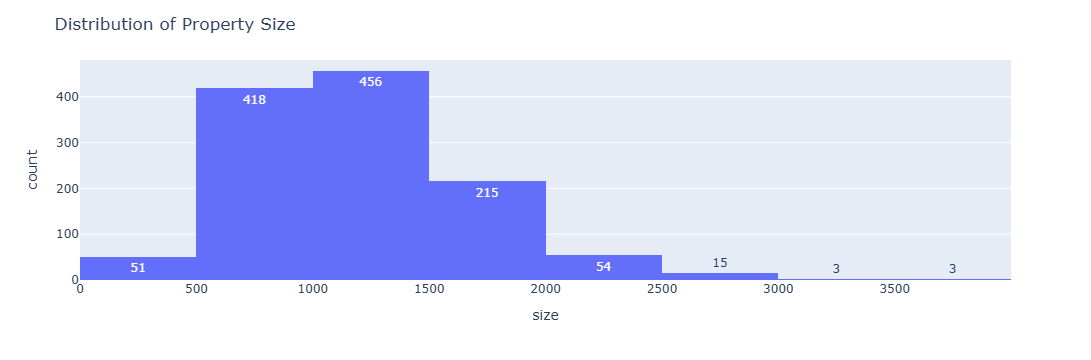

In [195]:
#Histogram
fig = px.histogram(df,x=df['size'],nbins=10,text_auto=True)
fig.update_layout(title='Distribution of Property Size')

###  **Insights**

* Most homes are medium-sized, mainly between **800–1500 sq. ft.**
* Very **few big homes** above 2000 sq. ft.
* **Small homes** below 500 sq. ft. are also very rare.
* The chart shows most properties are medium-sized, with only a **few very large ones**.


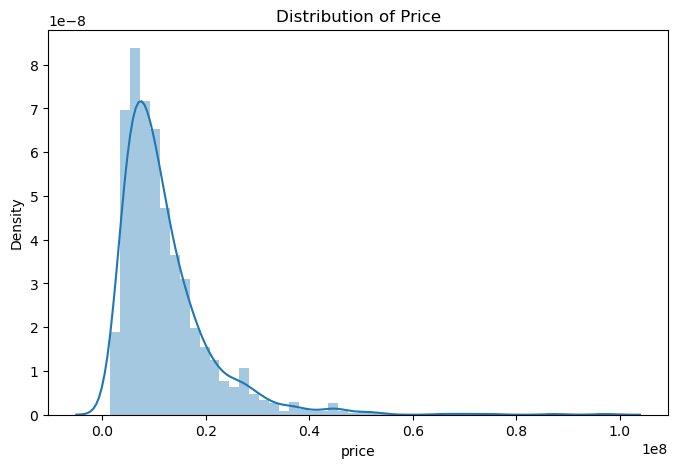

In [196]:
#Distplot
plt.figure(figsize=(8,5))
sns.distplot(df['price'])
plt.title('Distribution of Price');

###  **Insights**

- Most properties have prices on the lower side.
- Very few properties are extremely costly.
- The distribution is right-skewed.
- most homes are affordable to mid-range, and only a few are luxury-priced.

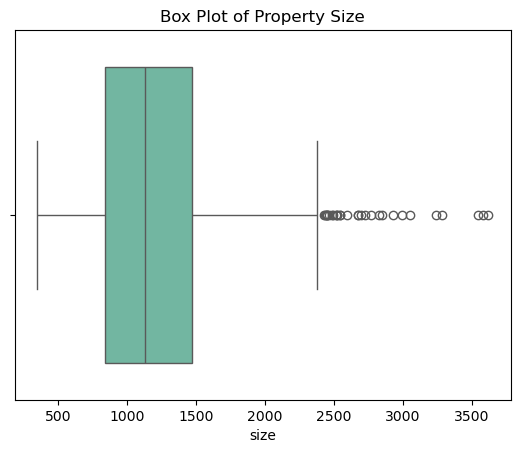

In [197]:
#Box Plot
sns.boxplot(x = df['size'],palette='Set2')
plt.title('Box Plot of Property Size');

###  **Insights**

* Most homes are between **900–1500 sq. ft.**, which is the main range shown by the box.
* There are many **large-size outliers** above 2500 sq. ft., meaning some homes are much bigger than the usual range.
* The median size is around **1200 sq. ft.**, showing that typical homes are mid-sized.

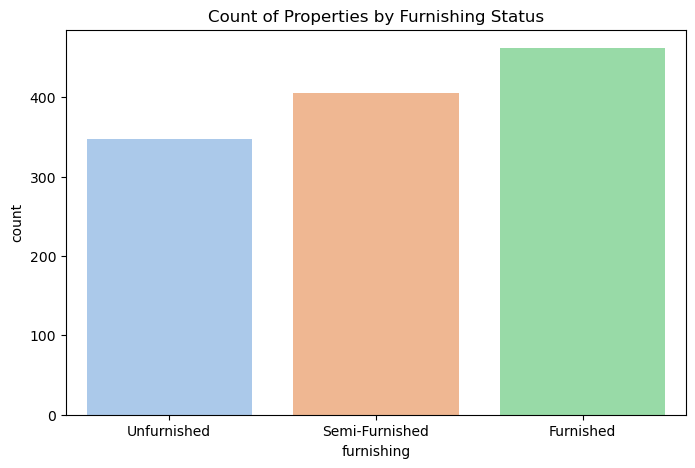

In [198]:
#Count Plot
plt.figure(figsize=(8,5))
sns.countplot(x=df['furnishing'],palette='pastel')
plt.title('Count of Properties by Furnishing Status');

###  **Insights**

* **Furnished properties are the most common**, showing the highest count.
* **Semi-furnished homes come next**, indicating moderate availability.
* **Unfurnished properties are the least**, meaning fewer raw or empty homes are listed.

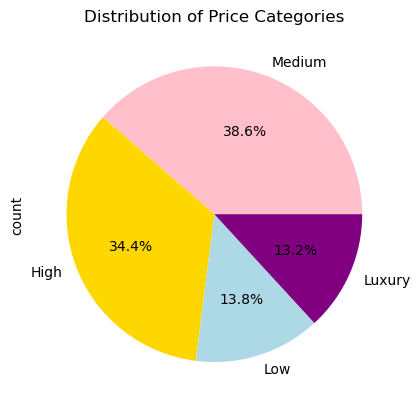

In [199]:
#Pie Chart
df['price_category'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                        colors = ['pink', 'gold', 'lightblue', 'purple'])
plt.title('Distribution of Price Categories');

###  **Insights**

* **Medium-priced properties are the most common**, making up the largest share (≈39%).
* **High-priced properties** come next with around **35%**.
* **Low-priced homes are fewer** (≈14%).
* **Luxury properties are the least common** (≈13%).

# *BI-Variate Analysis*

- *Numerical to Numerical*

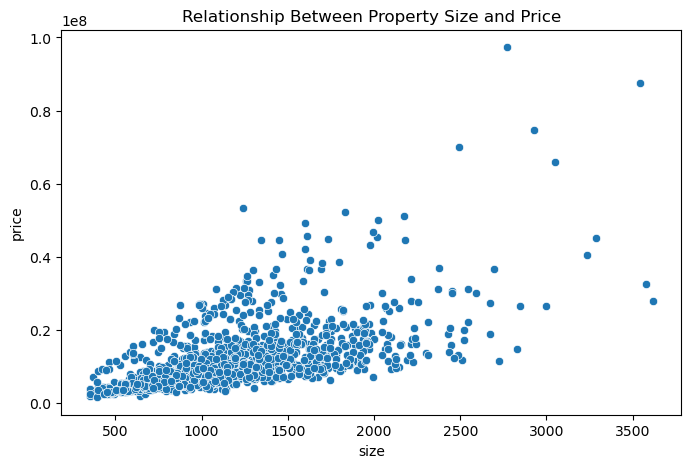

In [200]:
#Scatter Plot
plt.figure(figsize=(8,5))
sns.scatterplot(x = df['size'], y = df['price'])
plt.title('Relationship Between Property Size and Price');

###  **Insights**

* **Bigger homes generally cost more**.
* Most properties are clustered between **500–2000 sq. ft.** and **₹0–2 crore**.
* A few points are much higher in price, showing **luxury or premium properties**.
* The spread widens as size increases, meaning **large properties have more price variation**.

- *Numerical to Category*

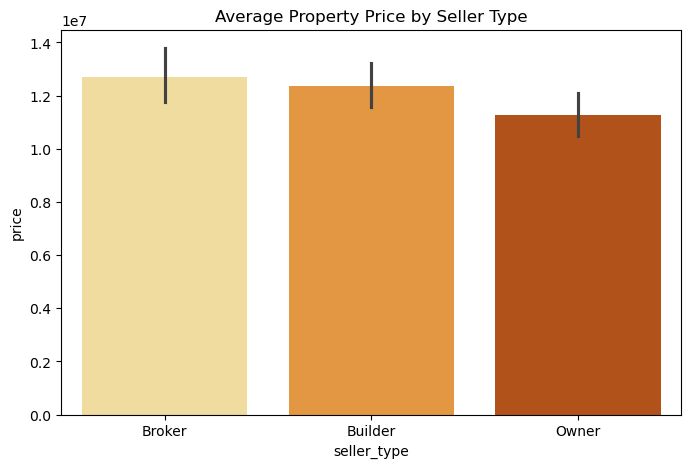

In [201]:
#Bar Plot
plt.figure(figsize=(8,5))
sns.barplot(x=df['seller_type'], y=df['price'], palette='YlOrBr')
plt.title('Average Property Price by Seller Type');

##  **Insights**

* **Broker-listed properties are the most expensive** on average.
* **Builder listings** have slightly lower prices compared to brokers but still on the higher side.
* **Owner-listed homes are the cheapest**, meaning owners tend to list at more affordable prices.

Text(0.5, 1.0, 'Price per Square Foot Across Major Indian Cities')

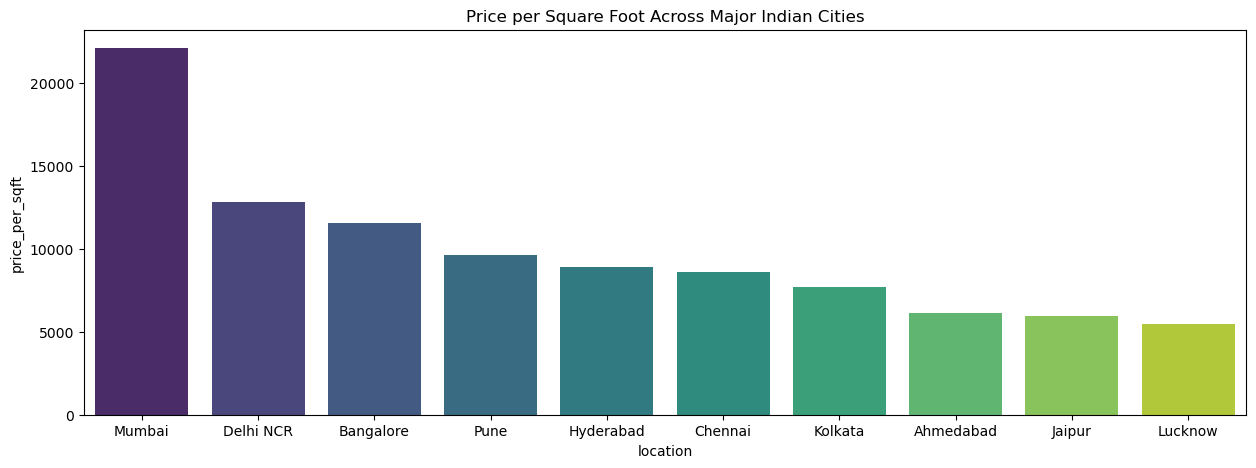

In [202]:
top = (df.groupby('location')['price_per_sqft'].mean().sort_values(ascending=False).reset_index())
plt.figure(figsize=(15,5))
sns.barplot(data=top, x='location', y='price_per_sqft', palette='viridis');
plt.title('Price per Square Foot Across Major Indian Cities')

##  **Insights**

* **Mumbai has the highest price per sq. ft.**, far above all other cities.
* **Delhi NCR and Bangalore** follow next, showing they are also high-demand and expensive markets.
* Cities like **Pune, Hyderabad, and Chennai** fall in the mid-range.
* **Lucknow, Jaipur, and Ahmedabad** have the **lowest prices**, making them more affordable for buyers.

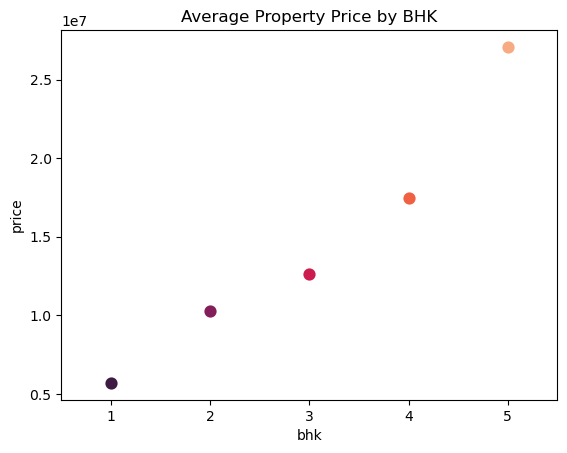

In [203]:
#Point Plot
bhk_price = df.groupby('bhk')['price'].mean().reset_index()
sns.pointplot(data = bhk_price, x = 'bhk', y='price',palette='rocket')
plt.title('Average Property Price by BHK');

##  **Insights**

* As the **number of BHK increases, the price also increases** steadily.
* **1 BHK homes are the cheapest**, while **5 BHK homes are the costliest**.
* The jump in price becomes more noticeable after **3 BHK**, showing bigger homes get much more expensive.

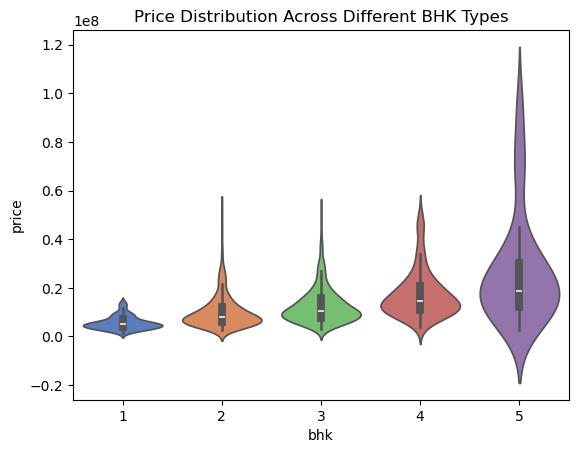

In [204]:
#Violin Plot
sns.violinplot(data=df,x='bhk',y='price',palette='muted')
plt.title('Price Distribution Across Different BHK Types');

##  **Insights**

* **Price increases as BHK increases**, with 5 BHK homes showing the highest spread.
* **1 BHK and 2 BHK properties have the lowest prices**.
* **Larger BHK homes (4–5 BHK) show a wide price range**, meaning they include both mid-range and luxury properties.
* The **5 BHK category has many very high-priced outliers**, indicating premium luxury homes.

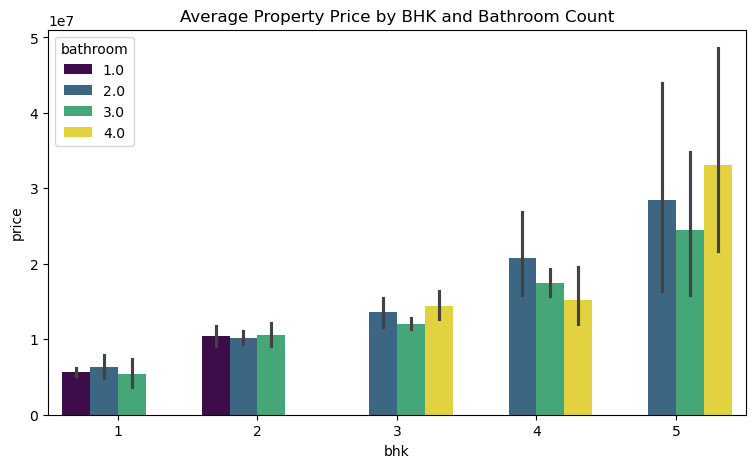

In [205]:
plt.figure(figsize=(9,5))
sns.barplot(df,x='bhk',y='price', hue='bathroom',palette='viridis')
plt.title('Average Property Price by BHK and Bathroom Count');

##  **Insights**

* **More BHK = higher price** — prices rise clearly from 1 BHK to 5 BHK.
* Within each BHK category, **properties with more bathrooms generally cost more**.
* **5 BHK homes with 4 bathrooms are the most expensive**, touching the luxury range.

- *Category To Category*

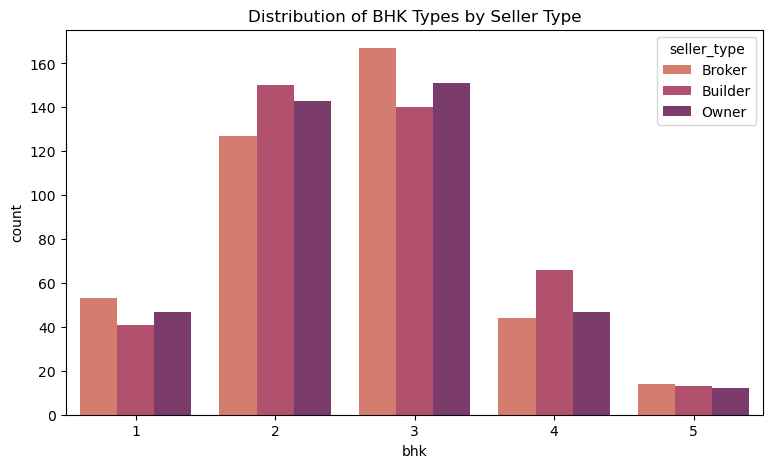

In [206]:
#Bar Plot

plt.figure(figsize=(9,5))
sns.countplot(x=df['bhk'], hue=df['seller_type'], palette='flare')
plt.title('Distribution of BHK Types by Seller Type');

##  **Insights**

* **2 BHK and 3 BHK homes are the most commonly listed** across all seller types.
* **Brokers and Owners list more 3 BHK properties** than Builders.
* **1 BHK and 5 BHK homes have the lowest listings**.
* **Builders list more 4 BHK homes** compared to Brokers and Owners, showing their focus on larger units.

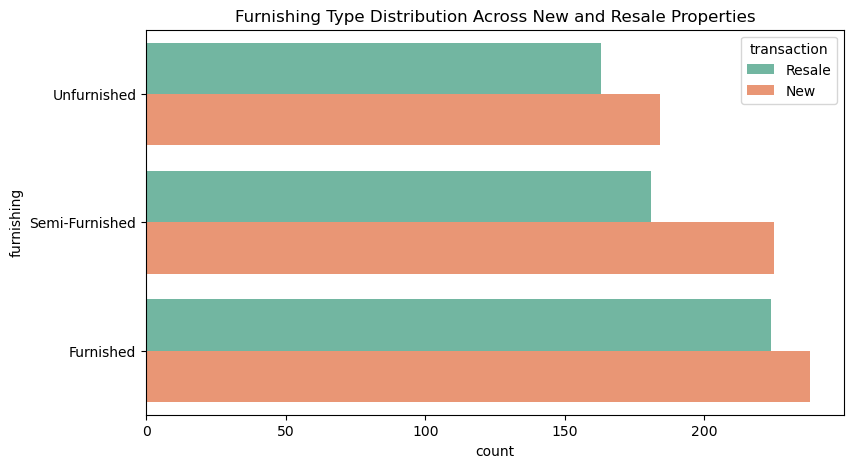

In [207]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, y=df['furnishing'], hue=df['transaction'], palette='Set2')
plt.title('Furnishing Type Distribution Across New and Resale Properties');

##  **Insights**

* **New properties are more common** across all furnishing levels (Furnished, Semi-Furnished, Unfurnished).
* **Furnished homes are the most popular** in both New and Resale categories.
* **Semi-furnished homes** also have high counts, especially among new listings.
* **Unfurnished homes are the least common**, especially for new properties — buyers prefer ready-to-move options.

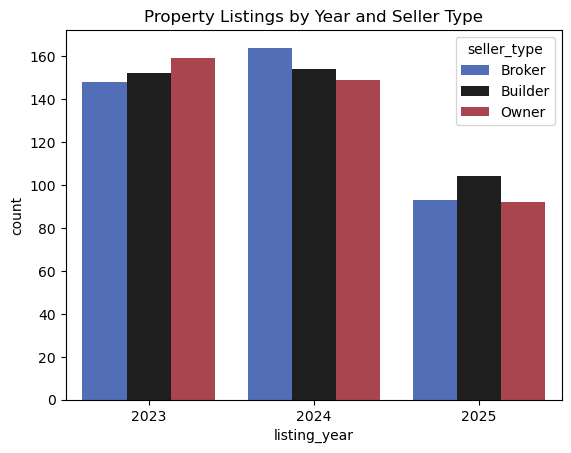

In [208]:
sns.countplot(df,x='listing_year', hue='seller_type',palette='icefire')
plt.title('Property Listings by Year and Seller Type');

##  **Insights**

* **2023 and 2024 have the highest number of listings** across all seller types.
* **Broker listings peak in 2024**.
* **Builders stay consistent**, with similar listing counts in 2023 and 2024.
* **2025 shows a drop in listings** for all seller types, especially Brokers and Owners.
* Overall, **Brokers and Owners listed more properties than Builders** in earlier years.

# *Multivariate Analysis* 

Text(0.5, 1.0, 'Correlation Heatmap of Price, Size, BHK, and Bathroom')

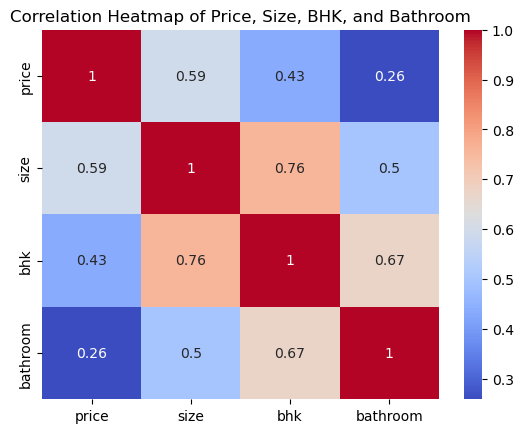

In [209]:
#Heatmap
corr_matrix = df[['price', 'size', 'bhk', 'bathroom']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Price, Size, BHK, and Bathroom')

##  **Insights**

* **Price is most strongly linked with size (0.59)** — bigger homes usually cost more.
* **BHK and size have a very strong relationship (0.76)** — more BHK → bigger house area.
* **Bathrooms also increase with BHK (0.67)** — larger homes have more bathrooms.
* **Price has a weaker link with bathrooms (0.26)**.

##  **Conclusion**

This real estate analysis helped us understand how different property features influence pricing and availability across cities and seller types. We explored key patterns using visualizations and found that:

* **Bigger properties (size, BHK, bathrooms)** generally come with **higher prices**.
* **City location plays a major role**, with metros like Mumbai, Delhi NCR, and Bangalore showing significantly higher price trends.
* **Furnishing, seller type, and transaction type** also impact pricing and listing distribution.
* Correlation analysis showed that **size, BHK, and bathrooms are strongly related**, confirming their combined effect on property value.

Overall, the dataset provides clear insights into buyer preferences, market behaviour, and pricing structure within the Indian real estate landscape.
This analysis can support **better decision-making** for buyers, sellers, investors, and developers.